# <span style='color:blue'>PART 3: WEB SCRAPING & HTML PARSING</span> ⏱️ 

---

## <span style='color:blue'>3.1 HTML Structure: Building Blocks of Web Pages</span>

**HTML is like a tree:**

```html
<html>          ← Root
  <head>        ← Branch
    <title>Page</title>   ← Leaf
  </head>
  <body>        ← Branch
    <div class="container">   ← Branch
      <h1>Title</h1>    ← Leaf
      <p>Content</p>    ← Leaf
    </div>
  </body>
</html>
```

**Key Concepts:**

```html
<!-- Element: <tag>content</tag> -->
<h1>This is a heading</h1>

<!-- Attributes: properties of elements -->
<div class="container" id="main" data-value="123">

<!-- Classes: for styling (can have multiple) -->
<div class="card featured important">

<!-- IDs: unique identifier (only one per page) -->
<div id="header">

<!-- Links -->
<a href="https://example.com">Click me</a>

<!-- Images -->
<img src="image.jpg" alt="Description">

<!-- Lists -->
<ul>
  <li>Item 1</li>
  <li>Item 2</li>
</ul>
```

## <span style='color:blue'>3.2 CSS Selectors: Finding Elements</span>

**CSS selectors** are patterns used to find and target specific HTML elements. They are the primary way to navigate and extract data from parsed HTML.

In [ ]:
from bs4 import BeautifulSoup

# Sample HTML structure used throughout this section
html = """
<div class="container">
  <article class="post" id="post-1">
    <h2 class="title">First Post</h2>
    <p class="content">This is content</p>
    <span class="author" data-id="123">Ahmed</span>
    <div class="tags">
      <a href="/tag/python">Python</a>
      <a href="/tag/data">Data</a>
    </div>
  </article>

  <article class="post featured" id="post-2">
    <h2 class="title">Second Post</h2>
    <p class="content">More content</p>
    <span class="author" data-id="456">Sara</span>
  </article>
</div>
"""

soup = BeautifulSoup(html, 'lxml')

# 1. By tag name — selects ALL <h2> elements
titles = soup.select('h2')
print("All titles:", [t.text for t in titles])

# 2. By class — selects elements with class='post'
posts = soup.select('.post')
print(f"Found {len(posts)} posts")

# 3. By ID — selects the single element with id='post-1'
post1 = soup.select_one('#post-1')
print("Post 1 title:", post1.select_one('h2').text)

# 4. Descendant (space = any level deep) — finds .author inside .post
authors = soup.select('.post .author')
print("Authors:", [a.text for a in authors])

# 5. Direct child (> = immediate child only)
container_children = soup.select('.container > article')
print(f"Direct children: {len(container_children)}")

# 6. Multiple classes — selects elements that have BOTH classes
featured = soup.select('.post.featured')
print(f"Featured posts: {len(featured)}")

# 7. Attribute selectors — [attr*='val'] means 'contains'
python_links = soup.select('a[href*="python"]')
print("Python links:", [l['href'] for l in python_links])

# 8. Starts with — [attr^='val'] means 'starts with'
tag_links = soup.select('a[href^="/tag"]')
print("Tag links:", len(tag_links))

# 9. Combine selectors — chain tag + class + descendant
post_titles = soup.select('article.post h2.title')
print("Post titles:", [t.text for t in post_titles])

# 10. Nth child — positional selectors
first_post = soup.select_one('article:first-child')
last_post = soup.select_one('article:last-child')
second_post = soup.select_one('article:nth-child(2)')

### <span style='color:red'>📌 Selector Cheat Sheet</span>

| **Selector** | **Example** | **Meaning** |
|---|---|---|
| `tag` | `div` | All `<div>` elements |
| `.class` | `.post` | Elements with `class="post"` |
| `#id` | `#main` | Element with `id="main"` |
| `tag.class` | `div.post` | `<div>` with `class="post"` |
| `tag tag` | `div p` | `<p>` inside `<div>` (any level) |
| `tag > tag` | `div > p` | Direct `<p>` child of `<div>` |
| `[attr]` | `[href]` | Elements with `href` attribute |
| `[attr="val"]` | `[href="/"]` | Exact match |
| `[attr^="val"]` | `[href^="http"]` | Starts with |
| `[attr$="val"]` | `[src$=".jpg"]` | Ends with |
| `[attr*="val"]` | `[class*="post"]` | Contains |
| `:first-child` | `li:first-child` | First child |
| `:last-child` | `li:last-child` | Last child |
| `:nth-child(n)` | `li:nth-child(2)` | Second child |

## <span style='color:blue'>3.3 BeautifulSoup Methods</span>

Three main methods for finding elements:
- **`find()`** — returns the **first** matching element
- **`find_all()`** — returns **all** matching elements as a list
- **`select()`** / **`select_one()`** — uses CSS selectors (**recommended**)

In [ ]:
# Reuse the soup object from the previous cell

# Method 1: find() - returns the FIRST match only
first_post = soup.find('article', class_='post')
print(first_post.find('h2').text)

# Method 2: find_all() - returns ALL matches as a list
all_posts = soup.find_all('article', class_='post')
for post in all_posts:
    print(post.find('h2').text)

# Method 3: select() - CSS selectors (RECOMMENDED for complex queries)
posts = soup.select('article.post')

# Extracting data from each matched element
for post in posts:
    # Get text content (strip=True removes leading/trailing whitespace)
    title = post.select_one('h2').get_text(strip=True)

    # Get attribute value using .get() (safer than direct dict access)
    post_id = post.get('id')  # same as post['id'] but doesn't raise KeyError
    author_id = post.select_one('.author').get('data-id')  # custom data-* attribute

    # Get text of all matching child elements as a list
    tags = [link.text for link in post.select('.tags a')]

    print(f"ID: {post_id}")
    print(f"Title: {title}")
    print(f"Author ID: {author_id}")
    print(f"Tags: {tags}")
    print("-" * 50)

# Navigate the tree using relationship properties
element = soup.select_one('h2')
parent = element.parent  # immediate parent element
next_sibling = element.find_next_sibling()  # next sibling element
previous = element.find_previous('div')  # previous <div> anywhere above

# Handle missing elements SAFELY — always check before accessing
price = soup.select_one('.price')
price_text = price.get_text() if price else 'N/A'  # fallback if element not found

# Use .get() with a default value for missing attributes
link = soup.select_one('a')
href = link.get('href', '#') if link else '#'  # default '#' if no href

## <span style='color:blue'>3.4 Real Example: Scraping Book Data</span>

**Scenario**: Scrape book information from [Books to Scrape](http://books.toscrape.com/) — a safe practice site designed for learning web scraping.

This section builds a full **`BookScraper`** class that:
- Scrapes multiple pages with **pagination**
- Follows links to get **detailed book info**
- Converts data to a **pandas DataFrame**
- Performs **analysis** on the collected data

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
from urllib.parse import urljoin  # Safely combines base URL + relative link


class BookScraper:
    """
    Scrape book data from books.toscrape.com
    """

    def __init__(self):
        self.base_url = 'http://books.toscrape.com'
        # Use a Session for persistent headers and connection reuse (more efficient)
        self.session = requests.Session()
        self.session.headers.update(
            {'User-Agent': 'Mozilla/5.0 (Educational Purpose) BookScraper/1.0'}
        )

    def scrape_page(self, url):
        """
        Scrape books from a single page.

        Returns:
            tuple: (list of books, next page URL)
        """
        try:
            response = self.session.get(url, timeout=10)
            response.raise_for_status()  # Raises exception for HTTP errors (4xx, 5xx)

            soup = BeautifulSoup(response.text, 'lxml')
            books = []

            # Find all book articles on the page
            for article in soup.select('article.product_pod'):
                book = {}

                # Title — stored in the 'title' attribute of the <a> tag (not text)
                title_element = article.select_one('h3 a')
                book['title'] = title_element.get('title')

                # Price — remove '£' symbol and convert to float
                price_text = article.select_one('.price_color').text
                book['price'] = float(price_text.replace('Â£', ''))

                # Availability — check if 'In stock' is in the text
                availability = article.select_one('.availability').text.strip()
                book['in_stock'] = 'In stock' in availability

                # Rating — stored as a CSS class like "star-rating Three"
                # We grab the second class name and map it to a number
                rating_element = article.select_one('.star-rating')
                rating_text = rating_element.get('class')[1]  # e.g., 'Three'
                rating_map = {'One': 1, 'Two': 2, 'Three': 3, 'Four': 4, 'Five': 5}
                book['rating'] = rating_map.get(rating_text, 0)

                # Book URL — combine base URL with relative link
                book_link = article.select_one('h3 a')['href']
                book['url'] = urljoin(url, book_link)

                books.append(book)

            # Find the 'next' button for pagination
            next_link = soup.select_one('.next a')
            next_url = urljoin(url, next_link['href']) if next_link else None

            return books, next_url

        except Exception as e:
            print(f"Error scraping {url}: {e}")
            return [], None

    def scrape_book_details(self, book_url):
        """
        Scrape detailed information from a book's individual page.
        """
        try:
            response = self.session.get(book_url, timeout=10)
            soup = BeautifulSoup(response.text, 'lxml')

            details = {}

            # Description — sibling <p> after the #product_description header
            desc_element = soup.select_one('#product_description ~ p')
            details['description'] = (
                desc_element.text if desc_element else 'No description'
            )

            # Category — extracted from the breadcrumb navigation
            breadcrumb = soup.select('.breadcrumb li')
            details['category'] = (
                breadcrumb[2].text.strip() if len(breadcrumb) > 2 else 'Unknown'
            )

            # Product information table — extract UPC and review count
            info_table = soup.select('.table.table-striped tr')
            for row in info_table:
                header = row.select_one('th').text.strip()
                value = row.select_one('td').text.strip()
                if header == 'UPC':
                    details['upc'] = value
                elif header == 'Number of reviews':
                    details['num_reviews'] = int(value)

            return details

        except Exception as e:
            print(f"Error fetching details: {e}")
            return {}

    def scrape_all_pages(self, max_pages=None):
        """
        Scrape multiple pages of books using pagination.
        """
        all_books = []
        url = f"{self.base_url}/catalogue/page-1.html"
        page = 1

        # Loop continues while there's a next page AND we haven't hit max_pages
        while url and (max_pages is None or page <= max_pages):
            print(f"📖 Scraping page {page}...")
            books, next_url = self.scrape_page(url)

            if books:
                all_books.extend(books)
                print(f"  Found {len(books)} books")

            url = next_url
            page += 1

            # Be polite — wait 1 second between requests to avoid overloading the server
            if url:
                time.sleep(1)

        print(f"\n✓ Total books scraped: {len(all_books)}")
        return all_books

    def scrape_with_details(self, max_pages=2, max_details=10):
        """
        Scrape books and fetch detailed info for first N books.
        """
        # Step 1: Get basic info for all books across pages
        books = self.scrape_all_pages(max_pages=max_pages)

        # Step 2: Fetch details for first N books only (to limit requests)
        print(f"\n📚 Fetching details for {max_details} books...")
        for i, book in enumerate(books[:max_details]):
            print(f"  {i+1}/{max_details}: {book['title'][:50]}...")
            details = self.scrape_book_details(book['url'])
            book.update(details)  # Merge detail fields into the book dict
            time.sleep(1)  # Polite delay between requests

        return books

    def to_dataframe(self, books):
        """Convert list of book dicts to DataFrame and add analysis columns."""
        df = pd.DataFrame(books)

        # Add a price category column using pd.cut() for binning
        df['price_category'] = pd.cut(
            df['price'],
            bins=[0, 20, 40, 60, float('inf')],
            labels=['Budget', 'Mid-range', 'Premium', 'Luxury'],
        )

        return df

    def analyze(self, df):
        """Perform analysis on book data and print a summary report."""
        print("\n" + "=" * 60)
        print("BOOK ANALYSIS REPORT")
        print("=" * 60)

        print(f"\n📊 Total Books: {len(df)}")
        print(f"💰 Average Price: £{df['price'].mean():.2f}")
        print(f"📈 Price Range: £{df['price'].min():.2f} - £{df['price'].max():.2f}")

        print(f"\n⭐ Rating Distribution:")
        print(df['rating'].value_counts().sort_index())

        print(f"\n💵 Books by Price Category:")
        print(df['price_category'].value_counts())

        if 'category' in df.columns:
            print(f"\n📚 Top 5 Categories:")
            print(df['category'].value_counts().head())

        print(f"\n📦 Stock Status:")
        print(df['in_stock'].value_counts())

        print(f"\n🏆 Top 5 Most Expensive Books:")
        top_expensive = df.nlargest(5, 'price')[['title', 'price', 'rating']]
        for idx, row in top_expensive.iterrows():
            print(f"  - {row['title'][:50]}: £{row['price']:.2f} ({row['rating']}★)")


# ── Usage ──────────────────────────────────────────────────────────────────
scraper = BookScraper()

# Scrape 3 pages (20 books per page = 60 books total)
books = scraper.scrape_all_pages(max_pages=3)
print(f"\nTotal books scraped: {len(books)}")

# Convert to DataFrame and run analysis
df = scraper.to_dataframe(books)
scraper.analyze(df)

# Save results to disk
df.to_csv('books_data.csv', index=False)
df.to_excel('books_data.xlsx', index=False)
print("\n💾 Data saved to books_data.csv and books_data.xlsx")

### Expected Output:

```
📖 Scraping page 1...
  Found 20 books
📖 Scraping page 2...
  Found 20 books
📖 Scraping page 3...
  Found 20 books

✓ Total books scraped: 60

============================================================
BOOK ANALYSIS REPORT
============================================================

📊 Total Books: 60
💰 Average Price: £35.72
📈 Price Range: £10.00 - £59.99

⭐ Rating Distribution:
1     4
2     8
3    14
4    20
5    14

💵 Books by Price Category:
Mid-range    28
Budget       18
Premium      10
Luxury        4

📦 Stock Status:
True     58
False     2

🏆 Top 5 Most Expensive Books:
  - Book Title Here: £59.99 (5★)
  ...
```

## <span style='color:blue'>3.5 Handling Dynamic Content</span>

**Problem**: Some websites load data with **JavaScript** *after* the initial page load. `BeautifulSoup` only sees the raw HTML — it **cannot execute JavaScript**!

### Solutions:

In [ ]:
# ── Option 1: Find the Hidden API (BEST approach) ─────────────────────────
#
# Instead of scraping rendered HTML, find the API the website uses internally!
# Steps:
#   1. Open Chrome DevTools (F12)
#   2. Go to "Network" tab
#   3. Filter by "Fetch/XHR"
#   4. Reload page or interact with the site
#   5. Look for JSON responses
#   6. Copy the URL and use it directly!

# Example: Many sites expose hidden APIs — much faster than scraping!
# import requests

# api_url = 'https://example.com/api/products?page=1'
# response = requests.get(api_url)
# data = response.json()  # Get clean, structured JSON directly — no HTML parsing needed!

# This is MUCH easier and faster than parsing HTML with BeautifulSoup!

In [ ]:
!pip install selenium webdriver-manager

In [ ]:
# ── Option 2: Use Selenium (If No API is Available) ───────────────────────
#
# Selenium controls a real browser, so JavaScript DOES execute.
# This is more complex and slower, but necessary for heavily JS-driven sites.
# Note: This is beyond the core scope but good to know!

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from bs4 import BeautifulSoup

# url = 'https://example.com'
url = 'https://www.hackerrank.com/'

# Launch a browser (requires ChromeDriver installed)
driver = webdriver.Chrome()
driver.get(url)

# Wait for a specific element to appear before scraping
# (avoids scraping before JS has finished loading content)
element = WebDriverWait(driver, 10).until(
    EC.presence_of_element_located((By.CLASS_NAME, "js-dynamic-word"))
)
print("Page loaded and dynamic content is present!")
print("Content: ", element.text)

# Now parse the fully-rendered page source with BeautifulSoup
soup = BeautifulSoup(driver.page_source, 'lxml')

driver.quit()  # Always close the browser when done

## <span style='color:blue'>3.6 robots.txt: The Rules</span>

<span style='color:red'>**⚠️ Always check `robots.txt` before scraping!**</span>

The `robots.txt` file at the root of every website tells bots which pages they are and aren't allowed to scrape.

In [4]:
from urllib.robotparser import RobotFileParser
from urllib.parse import urlparse, urljoin
import requests


def can_scrape(url, user_agent='*'):
    """
    Check if URL can be scraped according to robots.txt

    Args:
        url:        URL to check
        user_agent: Your bot's user agent string

    Returns:
        bool: True if allowed, False otherwise
    """
    try:
        # Build the robots.txt URL from the domain
        parsed = urlparse(url)
        robots_url = f"{parsed.scheme}://{parsed.netloc}/robots.txt"

        # Parse the robots.txt file
        rp = RobotFileParser()
        rp.set_url(robots_url)
        rp.read()

        # Check if our user_agent is allowed to access this URL
        allowed = rp.can_fetch(user_agent, url)

        if allowed:
            print(f"✅ Allowed: {url}")
        else:
            print(f"❌ Blocked: {url}")
            print(f"  Check {robots_url} for rules")

        return allowed

    except Exception as e:
        print(f"⚠️ Could not read robots.txt: {e}")
        print("  Proceed with caution and respect")
        return False


# Test: check if scraping is allowed for these URLs
can_scrape('http://books.toscrape.com/catalogue/page-1.html')
can_scrape('https://www.google.com/search?q=python')

# View the raw robots.txt file directly
response = requests.get('http://books.toscrape.com/robots.txt')
print(response.text)

✅ Allowed: http://books.toscrape.com/catalogue/page-1.html
❌ Blocked: https://www.google.com/search?q=python
  Check https://www.google.com/robots.txt for rules
❌ Blocked: https://www.google.com/search?q=python
  Check https://www.google.com/robots.txt for rules
<html>
<head><title>404 Not Found</title></head>
<body>
<center><h1>404 Not Found</h1></center>
<hr><center>nginx/1.21.6</center>
</body>
</html>

<html>
<head><title>404 Not Found</title></head>
<body>
<center><h1>404 Not Found</h1></center>
<hr><center>nginx/1.21.6</center>
</body>
</html>



### robots.txt Example:

```
User-agent: *
Disallow: /admin/
Disallow: /private/
Allow: /public/
Crawl-delay: 1
```

**What it means:**
- `User-agent: *` — applies to **all** bots
- `Disallow: /admin/` — don't scrape anything in `/admin/`
- `Allow: /public/` — `/public/` is OK
- `Crawl-delay: 1` — wait **1 second** between requests

## <span style='color:blue'>3.7 Best Practices & Ethics</span>

### ✅ DO:

**1. Check robots.txt first**
```python
can_scrape(url)
```

**2. Identify yourself**
```python
headers = {
    'User-Agent': 'MyBot/1.0 (+http://mywebsite.com/bot-info)'
}
```

**3. Add delays**
```python
time.sleep(random.uniform(1, 3))  # 1-3 seconds
```

**4. Cache results**
```python
# Don't re-scrape the same page
if url in cache:
    return cache[url]
```

**5. Handle errors gracefully**
```python
try:
    response = requests.get(url)
except Exception as e:
    print(f"Error: {e}")
```

**6. Respect the site**
```python
# Scrape during off-peak hours
# Limit concurrent requests
# Stop if you get blocked
```

---

### ❌ DON'T:

1. **Ignore `robots.txt`**
2. **Scrape personal data without consent**
3. **Overwhelm servers (DDoS)**
4. **Scrape if an API exists**
5. **Ignore copyright**
6. **Scrape login-protected content**

## <span style='color:red'>3.8 Graded Exercise 3: E-Commerce Analysis</span>

**Scenario**: Analyze the book market on [Books to Scrape](http://books.toscrape.com/)

---

### <span style='color:blue'>Task 1: Basic Scraping (15 points)</span>

**1.1** *(8 points)* — Scrape books from the **"Travel"** category
- Navigate to: http://books.toscrape.com/catalogue/category/books/travel_2/index.html
- Extract: `title`, `price`, `rating`, `availability`
- Handle pagination (all pages in category)
- Save as: `task1_travel_books.csv`

In [12]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
from urllib.parse import urljoin


def scrape_travel_books():
    """
    Scrape all travel books.

    Requirements:
    - Handle pagination
    - Add 1 second delay between pages
    - Extract all required fields

    Returns:
        DataFrame with book data
    """
    url = 'http://books.toscrape.com/catalogue/category/books/travel_2/index.html'

    session = requests.Session()
    session.headers.update({'User-Agent': 'Mozilla/5.0 (Educational Purpose) TravelScraper/1.0'})

    rating_map = {'One': 1, 'Two': 2, 'Three': 3, 'Four': 4, 'Five': 5}
    books = []
    page = 1

    while url:
        response = session.get(url, timeout=10)
        response.raise_for_status()
        soup = BeautifulSoup(response.text, 'lxml')

        for article in soup.select('article.product_pod'):
            book = {}

            title_element = article.select_one('h3 a')
            book['title'] = title_element.get('title')

            price_text = article.select_one('.price_color').text.strip()
            book['price'] = float(price_text.replace('£', '').replace('Â', ''))

            rating_class = article.select_one('.star-rating').get('class')[1]
            book['rating'] = rating_map.get(rating_class, 0)

            availability = article.select_one('.availability').text.strip()
            book['availability'] = availability
            book['in_stock'] = 'In stock' in availability

            books.append(book)

        print(f"  Found {len(soup.select('article.product_pod'))} books on this page")

        next_btn = soup.select_one('li.next a')
        if next_btn:
            url = urljoin(url, next_btn['href'])
            page += 1
            time.sleep(1)
        else:
            url = None

    print(f"\nTotal travel books scraped: {len(books)}")
    df = pd.DataFrame(books)
    df.to_csv('task1_travel_books.csv', index=False)
    print("Saved to task1_travel_books.csv")
    return df


df_travel = scrape_travel_books()
df_travel.head()


  Found 11 books on this page

Total travel books scraped: 11
Saved to task1_travel_books.csv


,title,price,rating,availability,in_stock
0,It's Only the Himalayas,45.17,2,In stock,True
1,Full Moon over Noahâs Ark: An Odyssey to Mou...,49.43,4,In stock,True
2,See America: A Celebration of Our National Par...,48.87,3,In stock,True
3,Vagabonding: An Uncommon Guide to the Art of L...,36.94,2,In stock,True
4,Under the Tuscan Sun,37.33,3,In stock,True


**1.2** *(7 points)* — Analysis questions:
- What's the average price of travel books?
- How many travel books are rated 5 stars?
- What percentage are in stock?

Save answers in: `task1_analysis.txt`

---

### <span style='color:blue'>Task 2: Multi-Category Comparison (20 points)</span>

**2.1** *(12 points)* — Scrape these categories:
- Fiction
- Mystery
- Historical Fiction
- Science Fiction

For each category:
- Scrape **first 2 pages only**
- Extract: `title`, `price`, `rating`, `category`
- Save combined data as: `task2_categories.csv`

**2.2** *(8 points)* — Comparative analysis:
- Which category has the **highest average rating**?
- Which has the **most expensive books** on average?
- Create a comparison visualization (save as `task2_comparison.png`)

40 books collected from 'Fiction'
32 books collected from 'Mystery'
32 books collected from 'Mystery'
26 books collected from 'Historical Fiction'
26 books collected from 'Historical Fiction'
16 books collected from 'Science Fiction'

Combined data saved to task2_categories.csv  (114 rows)

CATEGORY COMPARISON REPORT

Fiction (40 books)
   Avg Price  : £36.46  (£10.60 – £59.45)
   Avg Rating : 3.05
   In Stock   : 100.0%

Mystery (32 books)
   Avg Price  : £31.72  (£10.69 – £59.48)
   Avg Rating : 2.94
   In Stock   : 100.0%

Historical Fiction (26 books)
   Avg Price  : £33.64  (£16.62 – £55.55)
   Avg Rating : 3.23
   In Stock   : 100.0%

Science Fiction (16 books)
   Avg Price  : £33.80  (£10.65 – £54.86)
   Avg Rating : 2.25
   In Stock   : 100.0%

Highest avg rating  : Historical Fiction
Most expensive (avg): Fiction
16 books collected from 'Science Fiction'

Combined data saved to task2_categories.csv  (114 rows)

CATEGORY COMPARISON REPORT

Fiction (40 books)
   Avg Price  : £36

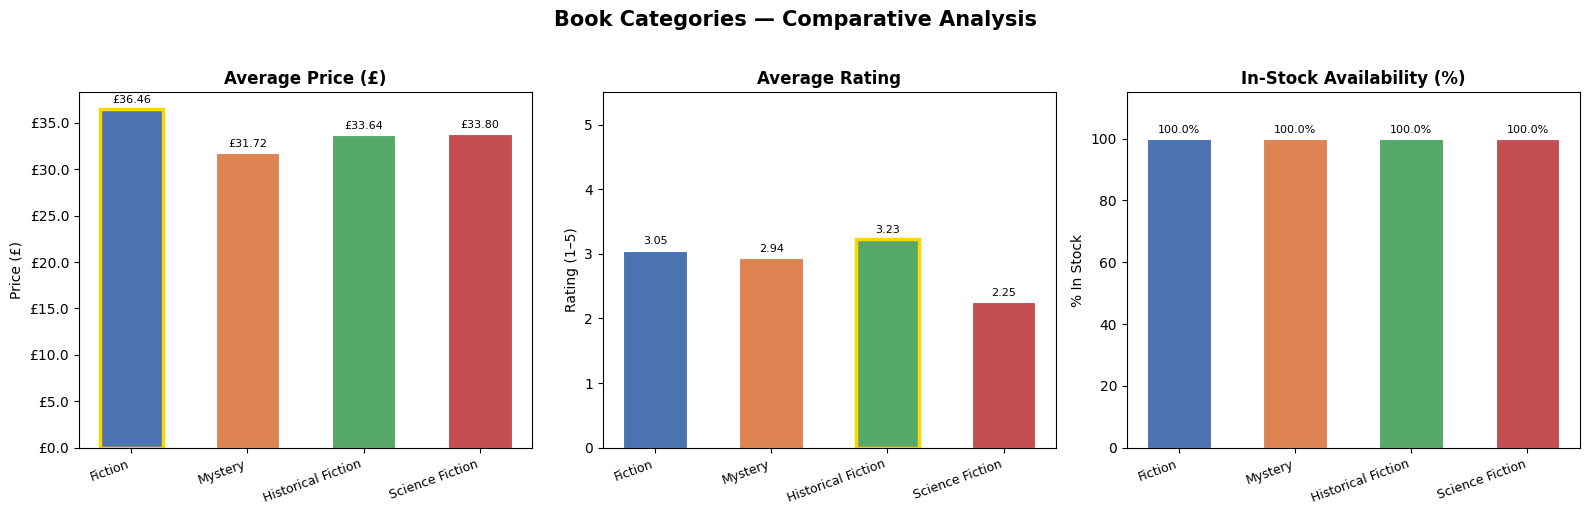


saved to task2_comparison.png


,title,price,rating,in_stock,category
0,Soumission,50.10,1,True,Fiction
1,Private Paris (Private #10),47.61,5,True,Fiction
2,"We Love You, Charlie Freeman",50.27,5,True,Fiction
3,Thirst,17.27,5,True,Fiction
4,The Murder That Never Was (Forensic Instincts #5),54.11,3,True,Fiction


In [ ]:

import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import time
from urllib.parse import urljoin


class CategoryScraper:
    """
    Scrape multiple categories and compare.
    """

    CATEGORY_SLUGS = {
        'Fiction':            'fiction_10',
        'Mystery':            'mystery_3',
        'Historical Fiction': 'historical-fiction_4',
        'Science Fiction':    'science-fiction_16',
    }

    RATING_MAP = {'One': 1, 'Two': 2, 'Three': 3, 'Four': 4, 'Five': 5}

    def __init__(self):
        self.base_url = 'http://books.toscrape.com'
        self.session = requests.Session()
        self.session.headers.update(
            {'User-Agent': 'Mozilla/5.0 (Educational Purpose) CategoryScraper/1.0'}
        )

    def scrape_category(self, category_name, max_pages=2):
        """
        Scrape books from a category (up to max_pages).

        Args:
            category_name: Human-readable category name (must be in CATEGORY_SLUGS)
            max_pages:     Maximum pages to scrape

        Returns:
            list: Book dictionaries with title, price, rating, category
        """
        slug = self.CATEGORY_SLUGS.get(category_name)
        if slug is None:
            raise ValueError(
                f"Unknown category '{category_name}'. "
                f"Available: {list(self.CATEGORY_SLUGS.keys())}"
            )

        url = f"{self.base_url}/catalogue/category/books/{slug}/index.html"
        books = []
        page = 1

        while url and page <= max_pages:
            try:
                response = self.session.get(url, timeout=10)
                response.raise_for_status()
                soup = BeautifulSoup(response.text, 'lxml')

                for article in soup.select('article.product_pod'):
                    book = {}

                    title_el = article.select_one('h3 a')
                    book['title'] = title_el.get('title', '').strip()

                    price_text = article.select_one('.price_color').text.strip()
                    book['price'] = float(
                        price_text.replace('£', '').replace('Â', '').strip()
                    )

                    rating_class = article.select_one('.star-rating').get('class')[1]
                    book['rating'] = self.RATING_MAP.get(rating_class, 0)

                    availability = article.select_one('.availability').text.strip()
                    book['in_stock'] = 'In stock' in availability
                    book['category'] = category_name
                    books.append(book)

                next_btn = soup.select_one('li.next a')
                url = urljoin(url, next_btn['href']) if next_btn else None
                page += 1

                if url and page <= max_pages:
                    time.sleep(1)

            except Exception as e:
                print(f"Error scraping {url}: {e}")
                break

        print(f"{len(books)} books collected from '{category_name}'")
        return books

    def scrape_multiple_categories(self, categories):
        """
        Scrape multiple categories and return a combined DataFrame.

        Args:
            categories: list of category names

        Returns:
            DataFrame with columns: title, price, rating, in_stock, category
        """
        all_books = []
        for cat in categories:
            books = self.scrape_category(cat, max_pages=2)
            all_books.extend(books)

        df = pd.DataFrame(all_books)
        df.to_csv('task2_categories.csv', index=False)
        print(f"\nCombined data saved to task2_categories.csv  ({len(df)} rows)")
        return df

    def compare_categories(self, df):
        """
        Comparative analysis across categories.

        Computes:
        - Average price per category
        - Average rating per category
        - In-stock percentage per category

        Returns:
            dict: Comparison statistics
        """
        stats = {}

        price_stats  = df.groupby('category')['price'].agg(['mean', 'min', 'max'])
        rating_stats = df.groupby('category')['rating'].mean()
        stock_pct    = df.groupby('category')['in_stock'].mean() * 100

        for cat in df['category'].unique():
            stats[cat] = {
                'avg_price':    round(price_stats.loc[cat, 'mean'], 2),
                'min_price':    round(price_stats.loc[cat, 'min'],  2),
                'max_price':    round(price_stats.loc[cat, 'max'],  2),
                'avg_rating':   round(rating_stats[cat], 2),
                'pct_in_stock': round(stock_pct[cat],    1),
                'book_count':   int((df['category'] == cat).sum()),
            }

        best_rated = max(stats, key=lambda c: stats[c]['avg_rating'])
        most_expensive = max(stats, key=lambda c: stats[c]['avg_price'])

        print("\n" + "=" * 60)
        print("CATEGORY COMPARISON REPORT")
        print("=" * 60)
        for cat, s in stats.items():
            print(
                f"\n{cat} ({s['book_count']} books)\n"
                f"   Avg Price  : £{s['avg_price']:.2f}  "
                f"(£{s['min_price']:.2f} – £{s['max_price']:.2f})\n"
                f"   Avg Rating : {s['avg_rating']:.2f}\n"
                f"   In Stock   : {s['pct_in_stock']:.1f}%"
            )

        print(f"\nHighest avg rating  : {best_rated}")
        print(f"Most expensive (avg): {most_expensive}")

        categories_order = list(stats.keys())
        summary = pd.DataFrame(stats).T.reindex(categories_order).reset_index()
        summary.columns = ['category', 'avg_price', 'min_price', 'max_price', 'avg_rating', 'pct_in_stock', 'book_count']
        summary = summary.astype({'avg_price': float, 'avg_rating': float, 'pct_in_stock': float, 'book_count': int})

        colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
        x = np.arange(len(summary))
        bar_w = 0.55

        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        fig.suptitle('Book Categories — Comparative Analysis', fontsize=15, fontweight='bold', y=1.02)

        ax1 = axes[0]
        bars1 = ax1.bar(x, summary['avg_price'], width=bar_w, color=colors, edgecolor='white', linewidth=0.8)
        ax1.set_title('Average Price (£)', fontsize=12, fontweight='bold')
        ax1.set_xticks(x)
        ax1.set_xticklabels(summary['category'], rotation=20, ha='right', fontsize=9)
        ax1.set_ylabel('Price (£)')
        ax1.yaxis.set_major_formatter(ticker.FormatStrFormatter('£%.1f'))
        ax1.bar_label(bars1, fmt='£%.2f', padding=3, fontsize=8)
        idx_exp = summary[summary['category'] == most_expensive].index[0]
        bars1[idx_exp].set_edgecolor('gold')
        bars1[idx_exp].set_linewidth(2.5)

        ax2 = axes[1]
        bars2 = ax2.bar(x, summary['avg_rating'], width=bar_w, color=colors,edgecolor='white', linewidth=0.8)
        ax2.set_title('Average Rating', fontsize=12, fontweight='bold')
        ax2.set_xticks(x)
        ax2.set_xticklabels(summary['category'], rotation=20, ha='right', fontsize=9)
        ax2.set_ylabel('Rating (1–5)')
        ax2.set_ylim(0, 5.5)
        ax2.bar_label(bars2, fmt='%.2f', padding=3, fontsize=8)
        idx_rat = summary[summary['category'] == best_rated].index[0]
        bars2[idx_rat].set_edgecolor('gold')
        bars2[idx_rat].set_linewidth(2.5)

        ax3 = axes[2]
        bars3 = ax3.bar(x, summary['pct_in_stock'], width=bar_w, color=colors,
                        edgecolor='white', linewidth=0.8)
        ax3.set_title('In-Stock Availability (%)', fontsize=12, fontweight='bold')
        ax3.set_xticks(x)
        ax3.set_xticklabels(summary['category'], rotation=20, ha='right', fontsize=9)
        ax3.set_ylabel('% In Stock')
        ax3.set_ylim(0, 115)
        ax3.bar_label(bars3, fmt='%.1f%%', padding=3, fontsize=8)

        plt.tight_layout()
        plt.savefig('task2_comparison.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("\nsaved to task2_comparison.png")
        return stats


cat_scraper = CategoryScraper()
categories = ['Fiction', 'Mystery', 'Historical Fiction', 'Science Fiction']
df_cats = cat_scraper.scrape_multiple_categories(categories)
stats = cat_scraper.compare_categories(df_cats)
df_cats.head()


### <span style='color:blue'>Task 3: Advanced Scraping Pipeline (15 points)</span>

**3.1** *(15 points)* — Build a **complete scraping system**

**Requirements:**

1. **Scraper Class** with:
   - Rate limiting (max **10 requests/minute**)
   - Retry logic (**3 attempts** with exponential backoff)
   - Logging (save to `scraper.log`)
   - `robots.txt` checker
   - Progress tracking

2. **Data Validation**:
   - Verify all prices are valid numbers
   - Check all ratings are 1–5
   - Ensure no duplicate books

3. **Error Recovery**:
   - If scraping fails, save progress
   - Resume from last successful page
   - Log all errors with timestamps

4. **Export Options**:
   - CSV with UTF-8 encoding
   - Excel with formatted headers
   - JSON with proper structure

In [1]:
import logging
from datetime import datetime
import json
from collections import deque
from urllib.robotparser import RobotFileParser
from urllib.parse import urlparse, urljoin
import requests
import time
from bs4 import BeautifulSoup
import pandas as pd


class AdvancedBookScraper:
    """
    Production-ready book scraper with logging, rate limiting, and error recovery.
    """
    CATEGORY_SLUGS = {
        'Fiction':            'fiction_10',
        'Mystery':            'mystery_3',
        'Historical Fiction': 'historical-fiction_4',
        'Science Fiction':    'science-fiction_16',
        'Fantasy':            'fantasy_19',
    }

    RATING_MAP = {'One': 1, 'Two': 2, 'Three': 3, 'Four': 4, 'Five': 5}

    def __init__(self, output_dir='scraped_data'):
        """
        Initialize scraper with logging and rate limiting.
        """
        # Setup file-based logging — all events will be written to scraper.log
        logging.basicConfig(
            filename='scraper.log',
            level=logging.INFO,
            format='%(asctime)s - %(levelname)s - %(message)s',
        )
        self.logger = logging.getLogger(__name__)

        # TODO: Add the following:
        # - Rate limiter (track request times to enforce max 10/min)
        # - requests.Session with proper headers
        # - Progress tracker (dict mapping page -> status)
        self.output_dir = output_dir
        self.rate_limiter = deque()
        self.max_requests  = 10
        self.time_window   = 60.0
        self.progress      = {}  
        self.base_url = 'http://books.toscrape.com'
        self.session = requests.Session()
        self.session.headers.update(
            {'User-Agent': 'Mozilla/5.0 (Educational Purpose) CategoryScraper/1.0'}
        )

    def wait_for_rate_limit(self):
        now = time.time()
        while self.rate_limiter and now - self.rate_limiter[0] > self.time_window:
            self.rate_limiter.popleft()

        if len(self.rate_limiter) >= self.max_requests:
            wait_time = self.time_window - (now - self.rate_limiter[0])
            print(f"Rate limit reached — waiting {wait_time:.1f}s...")
            time.sleep(wait_time)

        self.rate_limiter.append(time.time())

    def check_robots_txt(self, url):
        """
        Check if scraping is allowed for the given URL.
        """
        try:
            parsed = urlparse(url)
            robots_url = f"{parsed.scheme}://{parsed.netloc}/robots.txt"
            rp = RobotFileParser()
            rp.set_url(robots_url)
            rp.read()
            allowed = rp.can_fetch(self.session.headers['User-Agent'], url)
            return allowed

        except Exception as e:
            return False

    def scrape_with_retry(self, url, max_attempts=3):
        """
        Scrape a URL with exponential backoff on failure.
        Retry delays: 1s → 2s → 4s
        """
        for attempt in range(1, max_attempts + 1):
            try:
                self.wait_for_rate_limit()
                response = self.session.get(url, timeout=10)
                response.raise_for_status()
                return response.text

            except Exception as e:
                wait_time = 2 ** (attempt - 1)
                self.logger.warning(f"Attempt {attempt} failed for {url}: {e}")
                if attempt < max_attempts:
                    print(f"Retrying in {wait_time}s...")
                    time.sleep(wait_time)
                else:
                    self.logger.error(f"All attempts failed for {url}")
                    return None

    def validate_book_data(self, book):
        """
        Validate a book record before adding to results.

        Checks:
        - Price is a valid positive number
        - Rating is between 1 and 5
        - Title is not empty

        Returns:
            bool: True if valid
        """
        if not book.get('title'):
            self.logger.warning("Invalid book data: missing title")
            return False
        if not isinstance(book.get('price'), (int, float)) or book['price'] <= 0:
            self.logger.warning(f"Invalid price for book '{book.get('title')}': {book.get('price')}")
            return False
        if not (1 <= book.get('rating', 0) <= 5):
            self.logger.warning(f"Invalid rating for book '{book.get('title')}': {book.get('rating')}")
            return False
        return True

    def save_progress(self, books, filename='progress.json'):
        """
        Save current scraping progress to disk (for resumability).
        """
        data = {
            'timestamp': datetime.now().isoformat(),
            'book_count': len(books),
            'books': books,
        }
        with open(filename, 'w', encoding='utf-8') as f:
            json.dump(data, f, indent=2)
        self.logger.info(f"Progress saved: {len(books)} books → {filename}")

    def load_progress(self, filename='progress.json'):
        """
        Load previous progress from disk to resume interrupted scraping.
        """
        try:
            with open(filename, 'r', encoding='utf-8') as f:
                data = json.load(f)
            books = data.get('books', []) if isinstance(data, dict) else data
            self.progress = books
            self.logger.info(f"Resumed progress: {len(books)} books loaded from {filename}")
            return books

        except FileNotFoundError:
            self.logger.info("No previous progress found — starting fresh")
            return []

        except json.JSONDecodeError as e:
            self.logger.error(f"Corrupted progress file: {e}")
            return []

    def export_data(self, books, base_filename='task3_books'):
        """
        Export collected data to multiple file formats.

        Creates:
        - task3_books.csv   (UTF-8 encoded)
        - task3_books.xlsx  (with formatted headers)
        - task3_books.json  (properly structured)
        """
        df = pd.DataFrame(books)
        df.to_csv(f'{base_filename}.csv', index=False, encoding='utf-8')
        df.to_excel(f'{base_filename}.xlsx', index=False)
        with open(f'{base_filename}.json', 'w', encoding='utf-8') as f:
            json.dump(books, f, indent=2)
        self.logger.info(f"Data exported to {base_filename}.csv, .xlsx, and .json")
        self.logger.info(f"Exported {len(books)} books to {base_filename}.csv / .xlsx / .json")
        print(f"Exported {len(books)} books to {base_filename}.csv / .xlsx / .json")

    def run_full_pipeline(self, categories, max_pages_per_category=5):
        """
        Complete end-to-end scraping pipeline.

        Steps:
        1. Check robots.txt
        2. Load previous progress (if exists)
        3. Scrape each category
        4. Validate data
        5. Save progress after each category
        6. Export final results
        7. Generate summary report
        """
        accessible = self.check_robots_txt(self.base_url)

        if not accessible:
            self.logger.warning("Scraping not allowed by robots.txt")
            return

        previous = self.load_progress()
        if not previous:
            self.logger.info("No previous progress found, starting fresh.")

        all_books = list(previous)

        for category in categories:
            self.logger.info(f"Starting scrape for category: {category}")
            url = f"{self.base_url}/catalogue/category/books/{self.CATEGORY_SLUGS[category]}/index.html"
            books = []
            page = 1

            while url and page <= max_pages_per_category:
                html = self.scrape_with_retry(url)

                if not html:
                    self.logger.error(f"Failed to retrieve {url}")
                    break

                soup = BeautifulSoup(html, 'lxml')

                for article in soup.select('article.product_pod'):
                    book = {}

                    title_el = article.select_one('h3 a')
                    book['title'] = title_el.get('title', '').strip()

                    price_text = article.select_one('.price_color').text.strip()
                    book['price'] = float(
                        price_text.replace('£', '').replace('Â', '').strip()
                    )

                    rating_class = article.select_one('.star-rating').get('class')[1]
                    book['rating'] = self.RATING_MAP.get(rating_class, 0)

                    availability = article.select_one('.availability').text.strip()
                    book['in_stock'] = 'In stock' in availability
                    book['category'] = category
                    books.append(book)

                next_btn = soup.select_one('li.next a')
                url = urljoin(url, next_btn['href']) if next_btn else None
                page += 1

                if url and page <= max_pages_per_category:
                    time.sleep(1)

            valid_books = [b for b in books if self.validate_book_data(b)]
            all_books.extend(valid_books)
            self.save_progress(all_books)
            self.logger.info(f"Finished '{category}': {len(valid_books)} valid books")

        self.export_data(all_books)
        self.logger.info("Scraping pipeline completed.")

        print(f"\n{'='*50}")
        print(f"PIPELINE COMPLETE — {len(all_books)} total books")
        df_summary = pd.DataFrame(all_books)
        if not df_summary.empty:
            print(df_summary.groupby('category')[['price', 'rating']].mean().round(2))
        print(f"{'='*50}")


# Test your scraper:
scraper = AdvancedBookScraper()
scraper.run_full_pipeline(
    categories=['Mystery', 'Science Fiction', 'Fantasy'], max_pages_per_category=3
)

Exported 96 books to task3_books.csv / .xlsx / .json

PIPELINE COMPLETE — 96 total books
                 price  rating
category                      
Fantasy          39.59    3.08
Mystery          31.72    2.94
Science Fiction  33.80    2.25


---

### <span style='color:red'>📋 Submission Requirements</span>

**Files to submit:**

| # | File | Description |
|---|------|-------------|
| 1 | `book_scraper.py` | All code |
| 2 | `task1_travel_books.csv` | Travel books data |
| 3 | `task1_analysis.txt` | Task 1 analysis answers |
| 4 | `task2_categories.csv` | Multi-category data |
| 5 | `task2_comparison.png` | Comparison visualization |
| 6 | `task3_books.csv` | Advanced scraper CSV output |
| 7 | `task3_books.xlsx` | Advanced scraper Excel output |
| 8 | `task3_books.json` | Advanced scraper JSON output |
| 9 | `scraper.log` | Log file |
| 10 | `README.md` | Documentation |

**`README.md` should include:**
- How to run your code
- Dependencies needed
- Any issues encountered
- Key findings from analysis

---

### <span style='color:blue'>📊 Grading Rubric</span>

| Category | Weight | Criteria |
|---|---|---|
| **Functionality** | 40% | Correct data extraction, proper pagination, error handling |
| **Code Quality** | 30% | Clean & readable code, proper comments, logging implementation |
| **Data Quality** | 20% | Validation implemented, no duplicates, correct formatting |
| **Analysis** | 10% | Insights from data, visualization quality |